# **Mascota Generativa v8: CLIP zero-shot extendido + corrección manual**

**Autora:** Paulina Peralta • **Fecha:** 26 May 2026

**Objetivo:** Generar mascotas personalizadas en estilo Pixar a partir de los rasgos faciales del usuario, con un verificador externo basado en CLIP zero-shot extendido a 17 rasgos visuales, así también, una interfaz de corrección manual antes de generar la imagen.

![Python](https://img.shields.io/badge/Python-3.11-blue) ![MediaPipe](https://img.shields.io/badge/MediaPipe-FaceMesh-green) ![CLIP](https://img.shields.io/badge/CLIP-zero--shot-purple) ![Diffusers](https://img.shields.io/badge/Diffusers-CuteModel-orange)

## **Cambios respecto a la v7**

La v7 introdujo `VERIFICACIONES_CLIP` extendido a 17 rasgos y un rebalanceo de `PESOS_POR_RASGO`. Sin embargo, durante la construcción del cuaderno se perdió la celda que aplica CLIP a la imagen y crea la variable `predicciones_clip`, lo cual hacía que el voto suave fallara con `NameError`.

La v8 corrige este error estructural y deja la sección 4.5 con tres celdas en orden claro: carga de CLIP, definición de los queries y la función `predecir_con_clip`, y aplicación a la imagen de entrada con generación de `predicciones_clip`.

El resto del pipeline (geometría, ensemble, UI de corrección, prompt, generación) queda intacto. Esta es la versión funcional final del cuaderno.

## **0. Imports y configuración**

Importamos las librerías necesarias para captura de imagen, detección facial, carga de modelos PyTorch, ensemble por voto suave y generación con difusión.

In [1]:
import os
import io
import math
import json
import hashlib
import numpy as np
import pandas as pd

#OpenCV y PIL
import cv2
from PIL import Image

#MediaPipe
import mediapipe as mp

#PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as tv_models

#Diffusion
from diffusers import AutoPipelineForText2Image, LCMScheduler

#Visualizacion
import matplotlib.pyplot as plt
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


Verificamos el dispositivo y definimos las rutas a los tres modelos preentrenados de los compañeros.

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
print(f"Dispositivo detectado: {device}")
print(f"Precisión: {dtype}")

MODELOS_PT = {
    "resnet_kat": "resnet-18-kat.pt",
    "vit_kat":    "vit_multihead_best-kat.pt",
    "agus":       "final_model-agus.pt",
}

for nombre, ruta in MODELOS_PT.items():
    estado = "encontrado" if os.path.exists(ruta) else "FALTA"
    print(f"  {nombre}: {ruta} -> {estado}")

Dispositivo detectado: cpu
Precisión: torch.float32
  resnet_kat: resnet-18-kat.pt -> encontrado
  vit_kat: vit_multihead_best-kat.pt -> encontrado
  agus: final_model-agus.pt -> encontrado


Definimos el esquema completo de etiquetas. Esta es la fuente de verdad sobre qué rasgos predice el sistema y qué valores puede tomar cada uno. Incluye 17 rasgos del vocabulario original más `tono_piel_lab` que es la clasificación adicional en espacio LAB.

In [3]:
CLASS_LABELS = {
    'color_pelo':    ['negro', 'castano', 'rubio', 'pelirrojo', 'gris', 'calvo'],
    'textura_pelo':  ['liso', 'ondulado', 'rizado', 'muy_rizado'],
    'longitud_pelo': ['corto', 'medio', 'largo', 'calvo'],
    'cejas':         ['normales', 'arqueadas', 'pobladas', 'finas', 'rectas'],
    'forma_ojos':    ['almendrada', 'redonda', 'rasgada', 'caida', 'prominente'],
    'tamano_nariz':  ['pequena', 'mediana', 'grande'],
    'forma_nariz':   ['recta', 'aguilena', 'respingona', 'ancha'],
    'grosor_labios': ['finos', 'medianos', 'carnosos'],
    'pomulos':       ['planos', 'normales', 'altos', 'prominentes'],
    'mandibula':     ['suave', 'marcada', 'ancha', 'estrecha'],
    'barbilla':      ['redonda', 'puntiaguda', 'cuadrada', 'hendida'],
    'forma_cara':    ['oval', 'redonda', 'cuadrada', 'corazon', 'diamante', 'oblonga'],
    'vello_facial':  ['sin_barba', 'barba_corta', 'barba_larga', 'bigote'],
    'gafas':         [False, True],
    'pecas':         [False, True],
    'tono_piel':     ['muy_claro', 'claro', 'medio', 'oliva', 'bronceado', 'oscuro', 'muy_oscuro'],
    'rango_edad':    ['nino', 'joven', 'adulto', 'maduro', 'mayor'],
    'color_ojos':    ['azul', 'verde', 'avellana', 'marron', 'marron_oscuro', 'gris', 'negro'],
    'tono_piel_lab': ['muy_claro', 'claro', 'medio', 'oliva', 'bronceado', 'oscuro', 'muy_oscuro'],
}

# Esta es la configuración de heads compartida por los tres modelos.
# Como todos predicen el mismo conjunto de rasgos, es una sola config.
HEADS_CONFIG = {nombre: len(clases) for nombre, clases in CLASS_LABELS.items()}

print(f"Total de rasgos: {len(CLASS_LABELS)}")
print(f"Total de neuronas en heads sumadas: {sum(HEADS_CONFIG.values())}")

Total de rasgos: 19
Total de neuronas en heads sumadas: 86


## **1. Captura de la imagen**

Soportamos webcam y archivo local de forma a poder iterar tanto en demo en vivo como en pruebas reproducibles.

In [4]:
def capturar_webcam(camera_index: int = 0, warmup_frames: int = 10):
    cap = cv2.VideoCapture(camera_index, cv2.CAP_DSHOW)
    if not cap.isOpened():
        cap.release()
        return None
    frame = None
    for _ in range(warmup_frames):
        ret, frame = cap.read()
        if not ret:
            frame = None
            break
    cap.release()
    if frame is None:
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

def cargar_desde_archivo(ruta: str):
    img_bgr = cv2.imread(ruta)
    if img_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen en {ruta}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

En Windows usamos `cv2.CAP_DSHOW` ya que el backend por defecto suele tardar o fallar al abrir la cámara.

Imagen cargada con shape: (391, 391, 3)


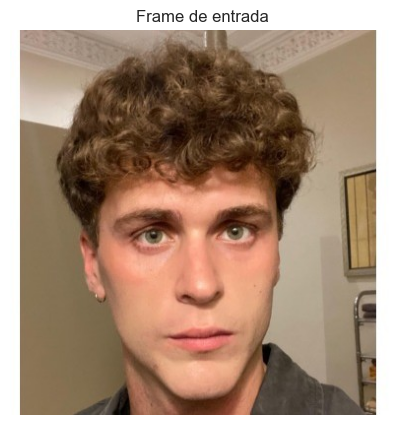

In [5]:
ruta_prueba = "rostro_agus.jpeg"

if os.path.exists(ruta_prueba):
    imagen = cargar_desde_archivo(ruta_prueba)
else:
    imagen = capturar_webcam()

if imagen is not None:
    print(f"Imagen cargada con shape: {imagen.shape}")
    plt.figure(figsize=(5, 5))
    plt.imshow(imagen)
    plt.axis('off')
    plt.title("Frame de entrada")
    plt.show()
else:
    print("Sin imagen disponible.")

## **2. Detección facial con MediaPipe**

Inicializamos Face Mesh con `refine_landmarks=True` lo cual nos da 478 puntos incluyendo los del iris. Estos landmarks alimentan toda la extracción geométrica de la siguiente sección.

In [6]:
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
)

resultado = face_mesh.process(imagen)

if resultado.multi_face_landmarks:
    landmarks = resultado.multi_face_landmarks[0].landmark
    print(f"Landmarks detectados: {len(landmarks)}")
else:
    landmarks = None
    print("No se detectó ninguna cara en la imagen.")

Landmarks detectados: 478


## **3. Extracción geométrica de rasgos**

A partir de los 478 landmarks construimos descriptores geométricos. Esta etapa no usa modelos de ML, lo cual la hace rápida y transparente. Cubre 11 de los 18 rasgos del vocabulario, los que se pueden derivar de geometría y muestreo de píxeles. Los 7 restantes (textura/longitud de pelo, cejas, vello facial, gafas, pecas, rango de edad, tono_piel_lab) los obtenemos del ensemble de modelos.

In [7]:
def punto_a_xy(landmarks, idx, ancho, alto):
    return np.array([landmarks[idx].x * ancho, landmarks[idx].y * alto])

def distancia_landmarks(landmarks, idx_a, idx_b, ancho, alto):
    a = punto_a_xy(landmarks, idx_a, ancho, alto)
    b = punto_a_xy(landmarks, idx_b, ancho, alto)
    return np.linalg.norm(a - b)

def muestrear_color(imagen_rgb, landmarks, indices, radio: int = 4):
    h, w = imagen_rgb.shape[:2]
    pixeles = []
    for idx in indices:
        x = int(landmarks[idx].x * w)
        y = int(landmarks[idx].y * h)
        x1, y1 = max(0, x - radio), max(0, y - radio)
        x2, y2 = min(w, x + radio), min(h, y + radio)
        parche = imagen_rgb[y1:y2, x1:x2]
        if parche.size > 0:
            pixeles.append(parche.reshape(-1, 3).mean(axis=0))
    if not pixeles:
        return None
    return np.mean(pixeles, axis=0)

def color_a_nombre(rgb, paleta):
    rgb = np.array(rgb)
    distancias = {nombre: np.linalg.norm(rgb - np.array(ref)) for nombre, ref in paleta.items()}
    return min(distancias, key=distancias.get)

### **3.1 Colores base**

Las paletas se alinean con el vocabulario de `CLASS_LABELS` lo cual garantiza que la heurística geométrica devuelve valores compatibles con los modelos.

In [8]:
PALETA_OJOS = {
    'azul':          (70, 130, 180),
    'verde':         (90, 140, 90),
    'avellana':      (140, 110, 70),
    'marron':        (90, 60, 40),
    'marron_oscuro': (50, 30, 20),
    'gris':          (130, 130, 130),
    'negro':         (25, 25, 25),
}

PALETA_PIEL = {
    'muy_claro':  (240, 220, 200),
    'claro':      (220, 190, 170),
    'medio':      (200, 160, 130),
    'oliva':      (180, 150, 110),
    'bronceado':  (170, 120, 90),
    'oscuro':     (110, 70, 50),
    'muy_oscuro': (70, 40, 30),
}

PALETA_PELO = {
    'negro':       (30, 25, 25),
    'castano':     (90, 65, 50),
    'rubio':       (200, 170, 110),
    'pelirrojo':   (160, 80, 50),
    'gris':        (150, 150, 150),
}

IRIS_DERECHO = [469, 470, 471, 472]
IRIS_IZQUIERDO = [474, 475, 476, 477]
MEJILLA_DERECHA = [50, 101, 36, 205]
MEJILLA_IZQUIERDA = [280, 330, 266, 425]

In [9]:
def extraer_colores_base(imagen_rgb, landmarks):
    color_ojos_rgb = muestrear_color(imagen_rgb, landmarks, IRIS_DERECHO + IRIS_IZQUIERDO, radio=2)
    color_piel_rgb = muestrear_color(imagen_rgb, landmarks, MEJILLA_DERECHA + MEJILLA_IZQUIERDA, radio=8)

    h, w = imagen_rgb.shape[:2]
    frente = landmarks[10]
    menton = landmarks[152]
    altura_cara = abs(menton.y - frente.y) * h
    x = int(frente.x * w)
    y = max(0, int(frente.y * h - 0.12 * altura_cara))
    parche_pelo = imagen_rgb[max(0, y - 12):y + 12, max(0, x - 12):x + 12]
    color_pelo_rgb = parche_pelo.reshape(-1, 3).mean(axis=0) if parche_pelo.size > 0 else None

    return {
        'color_ojos': color_a_nombre(color_ojos_rgb, PALETA_OJOS),
        'tono_piel':  color_a_nombre(color_piel_rgb, PALETA_PIEL),
        'color_pelo': color_a_nombre(color_pelo_rgb, PALETA_PELO) if color_pelo_rgb is not None else 'castano',
        '_color_ojos_rgb': tuple(int(v) for v in color_ojos_rgb),
        '_color_piel_rgb': tuple(int(v) for v in color_piel_rgb),
        '_color_pelo_rgb': tuple(int(v) for v in color_pelo_rgb) if color_pelo_rgb is not None else None,
    }

colores_base = extraer_colores_base(imagen, landmarks)
for k, v in colores_base.items():
    if not k.startswith('_'):
        print(f"  {k}: {v}")

  color_ojos: avellana
  tono_piel: medio
  color_pelo: castano


### **3.2 Forma de la cara**

Calculamos tres ratios geométricos sobre la cara: aspecto (altura/ancho), mandíbula sobre pómulos, y frente sobre pómulos. Con esos descriptores discriminamos entre las seis formas del vocabulario.

In [10]:
def calcular_forma_cara(imagen_rgb, landmarks):
    h, w = imagen_rgb.shape[:2]
    altura       = distancia_landmarks(landmarks, 10, 152, w, h)
    ancho_pom    = distancia_landmarks(landmarks, 234, 454, w, h)
    ancho_mand   = distancia_landmarks(landmarks, 172, 397, w, h)
    ancho_frente = distancia_landmarks(landmarks, 21, 251, w, h)

    ratio_aspecto = altura / ancho_pom
    ratio_mand    = ancho_mand / ancho_pom
    ratio_frente  = ancho_frente / ancho_pom

    if ratio_aspecto > 1.5:
        forma = 'oblonga'
    elif ratio_aspecto < 1.05 and ratio_mand > 0.85:
        forma = 'redonda'
    elif ratio_mand > 0.95 and ratio_aspecto < 1.25:
        forma = 'cuadrada'
    elif ratio_frente > 0.9 and ratio_mand < 0.75:
        forma = 'corazon'
    elif ratio_frente < 0.75 and ratio_mand < 0.75:
        forma = 'diamante'
    else:
        forma = 'oval'

    return {
        'forma_cara': forma,
        '_ratio_aspecto':  round(float(ratio_aspecto), 3),
        '_ratio_mandibula': round(float(ratio_mand), 3),
        '_ratio_frente':   round(float(ratio_frente), 3),
    }

print(calcular_forma_cara(imagen, landmarks))

{'forma_cara': 'oval', '_ratio_aspecto': 1.267, '_ratio_mandibula': 0.793, '_ratio_frente': 0.97}


### **3.3 Forma y tamaño de los ojos**

La forma se deriva del ratio entre el ancho y la altura del ojo, y del ángulo del canto externo respecto al interno. Las cinco categorías se discriminan combinando ambas medidas.

In [11]:
def calcular_forma_ojos(imagen_rgb, landmarks):
    h, w = imagen_rgb.shape[:2]

    ancho_d = distancia_landmarks(landmarks, 33, 133, w, h)
    alto_d  = distancia_landmarks(landmarks, 159, 145, w, h)
    ancho_i = distancia_landmarks(landmarks, 362, 263, w, h)
    alto_i  = distancia_landmarks(landmarks, 386, 374, w, h)

    ratio_ar_d = ancho_d / max(alto_d, 1e-6)
    ratio_ar_i = ancho_i / max(alto_i, 1e-6)
    ratio_ar = (ratio_ar_d + ratio_ar_i) / 2

    p_int = punto_a_xy(landmarks, 33, w, h)
    p_ext = punto_a_xy(landmarks, 133, w, h)
    delta = p_ext - p_int
    angulo = math.degrees(math.atan2(delta[1], delta[0]))

    if ratio_ar > 3.2 and angulo < -3:
        forma = 'rasgada'
    elif ratio_ar > 3.2 and angulo > 3:
        forma = 'caida'
    elif ratio_ar < 2.4:
        forma = 'redonda'
    elif alto_d / max(ancho_d, 1e-6) > 0.45:
        forma = 'prominente'
    else:
        forma = 'almendrada'

    return {
        'forma_ojos': forma,
        '_ratio_ojo_ar': round(float(ratio_ar), 3),
        '_angulo_canto': round(float(angulo), 2),
    }

print(calcular_forma_ojos(imagen, landmarks))

{'forma_ojos': 'almendrada', '_ratio_ojo_ar': 2.678, '_angulo_canto': 1.53}


### **3.4 Forma y tamaño de la nariz**

El tamaño se mide como el ratio entre la altura de la nariz y la altura total de la cara. Para la forma combinamos ancho de la base y orientación del tip respecto al puente.

In [12]:
def calcular_forma_nariz(imagen_rgb, landmarks):
    h, w = imagen_rgb.shape[:2]

    altura_nariz = distancia_landmarks(landmarks, 8, 2, w, h)
    altura_cara  = distancia_landmarks(landmarks, 10, 152, w, h)
    ancho_nariz  = distancia_landmarks(landmarks, 49, 279, w, h)
    ancho_cara   = distancia_landmarks(landmarks, 234, 454, w, h)

    ratio_altura = altura_nariz / max(altura_cara, 1e-6)
    ratio_ancho  = ancho_nariz / max(ancho_cara, 1e-6)

    if ratio_altura < 0.27:
        tamano = 'pequena'
    elif ratio_altura > 0.34:
        tamano = 'grande'
    else:
        tamano = 'mediana'

    puente = punto_a_xy(landmarks, 6, w, h)
    tip    = punto_a_xy(landmarks, 2, w, h)
    base   = punto_a_xy(landmarks, 1, w, h)
    desplaz_tip = tip[0] - puente[0]
    levanta_tip = base[1] - tip[1]

    if ratio_ancho > 0.32:
        forma = 'ancha'
    elif levanta_tip < -3:
        forma = 'respingona'
    elif abs(desplaz_tip) < 2 and levanta_tip > 3:
        forma = 'aguilena'
    else:
        forma = 'recta'

    return {
        'tamano_nariz': tamano,
        'forma_nariz':  forma,
        '_ratio_altura_nariz': round(float(ratio_altura), 3),
        '_ratio_ancho_nariz':  round(float(ratio_ancho), 3),
    }

print(calcular_forma_nariz(imagen, landmarks))

{'tamano_nariz': 'grande', 'forma_nariz': 'respingona', '_ratio_altura_nariz': 0.358, '_ratio_ancho_nariz': 0.31}


### **3.5 Grosor de los labios**

Se mide como la suma de la altura del labio superior y la del inferior, normalizada por el ancho de la boca. El resultado es invariante a la escala.

In [13]:
def calcular_grosor_labios(imagen_rgb, landmarks):
    h, w = imagen_rgb.shape[:2]

    alto_sup = distancia_landmarks(landmarks, 0, 13, w, h)
    alto_inf = distancia_landmarks(landmarks, 14, 17, w, h)
    ancho_boca = distancia_landmarks(landmarks, 61, 291, w, h)

    grosor_norm = (alto_sup + alto_inf) / max(ancho_boca, 1e-6)

    if grosor_norm < 0.22:
        grosor = 'finos'
    elif grosor_norm > 0.34:
        grosor = 'carnosos'
    else:
        grosor = 'medianos'

    return {
        'grosor_labios': grosor,
        '_grosor_norm': round(float(grosor_norm), 3),
    }

print(calcular_grosor_labios(imagen, landmarks))

{'grosor_labios': 'medianos', '_grosor_norm': 0.327}


### **3.6 Pómulos, mandíbula y barbilla**

Estos tres rasgos describen la estructura ósea inferior. Pómulos por posición vertical relativa, mandíbula por ratio respecto a pómulos, barbilla por el ángulo del mentón.

In [14]:
def calcular_estructura_inferior(imagen_rgb, landmarks):
    h, w = imagen_rgb.shape[:2]

    pomulo  = punto_a_xy(landmarks, 234, w, h)
    frente  = punto_a_xy(landmarks, 10, w, h)
    menton  = punto_a_xy(landmarks, 152, w, h)
    altura_cara = menton[1] - frente[1]
    pos_pomulo = (pomulo[1] - frente[1]) / max(altura_cara, 1e-6)

    if pos_pomulo < 0.35:
        pomulos = 'altos'
    elif pos_pomulo > 0.48:
        pomulos = 'planos'
    else:
        pomulos = 'normales'

    ancho_pom = distancia_landmarks(landmarks, 234, 454, w, h)
    ancho_mand = distancia_landmarks(landmarks, 172, 397, w, h)
    ratio_mand = ancho_mand / max(ancho_pom, 1e-6)

    if ratio_mand < 0.72:
        mandibula = 'estrecha'
    elif ratio_mand > 0.92:
        mandibula = 'ancha'
    elif ratio_mand > 0.85:
        mandibula = 'marcada'
    else:
        mandibula = 'suave'

    p_izq = punto_a_xy(landmarks, 176, w, h)
    p_med = punto_a_xy(landmarks, 152, w, h)
    p_der = punto_a_xy(landmarks, 400, w, h)
    v1 = p_izq - p_med
    v2 = p_der - p_med
    cos_ang = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6)
    angulo_barbilla = math.degrees(math.acos(np.clip(cos_ang, -1.0, 1.0)))

    if angulo_barbilla < 110:
        barbilla = 'puntiaguda'
    elif angulo_barbilla > 150:
        barbilla = 'cuadrada'
    else:
        barbilla = 'redonda'

    return {
        'pomulos':   pomulos,
        'mandibula': mandibula,
        'barbilla':  barbilla,
        '_pos_pomulo': round(float(pos_pomulo), 3),
        '_ratio_mand': round(float(ratio_mand), 3),
        '_angulo_barbilla': round(float(angulo_barbilla), 2),
    }

print(calcular_estructura_inferior(imagen, landmarks))

{'pomulos': 'normales', 'mandibula': 'suave', 'barbilla': 'redonda', '_pos_pomulo': 0.393, '_ratio_mand': 0.793, '_angulo_barbilla': 146.94}


### **3.7 Consolidación de rasgos geométricos**

Juntamos todo en un diccionario único que será una de las fuentes del ensemble.

In [15]:
def extraer_rasgos_geometricos(imagen_rgb, landmarks):
    rasgos = {}
    rasgos.update(extraer_colores_base(imagen_rgb, landmarks))
    rasgos.update(calcular_forma_cara(imagen_rgb, landmarks))
    rasgos.update(calcular_forma_ojos(imagen_rgb, landmarks))
    rasgos.update(calcular_forma_nariz(imagen_rgb, landmarks))
    rasgos.update(calcular_grosor_labios(imagen_rgb, landmarks))
    rasgos.update(calcular_estructura_inferior(imagen_rgb, landmarks))
    return rasgos

rasgos_geom = extraer_rasgos_geometricos(imagen, landmarks)
publicos = {k: v for k, v in rasgos_geom.items() if not k.startswith('_')}
pd.DataFrame([publicos]).T.rename(columns={0: "valor"})

,valor
color_ojos,avellana
tono_piel,medio
color_pelo,castano
forma_cara,oval
forma_ojos,almendrada
tamano_nariz,grande
forma_nariz,respingona
grosor_labios,medianos
pomulos,normales
mandibula,suave


Se visualizan los 11 rasgos que la geometría cubre. Los 7 restantes los completaremos con el ensemble de modelos en la siguiente sección.

## **4. Modelos preentrenados de los compañeros**

Los tres modelos predicen el mismo conjunto de 18 rasgos, lo cual nos permite hacer ensemble verdadero entre ellos. Las arquitecturas son distintas (ResNet18 y ViT) lo cual es bueno para el ensemble ya que modelos diversos suelen complementarse mejor que modelos homogéneos.

### **4.1 Inspección de los checkpoints**

Antes de cargar los modelos inspeccionamos las keys del `state_dict` para verificar que nuestra arquitectura propuesta coincide con la entrenada por los compañeros.

In [16]:
def inspeccionar_pt(ruta):
    if not os.path.exists(ruta):
        print(f"  No existe: {ruta}")
        return None
    checkpoint = torch.load(ruta, map_location='cpu', weights_only=False)

    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
        extras = {k: v for k, v in checkpoint.items() if k != 'state_dict'}
    elif isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
        extras = {k: v for k, v in checkpoint.items() if k != 'model_state_dict'}
    elif isinstance(checkpoint, dict):
        state_dict = checkpoint
        extras = {}
    else:
        return None
    return state_dict, extras

def shape_safe(v):
    """Devuelve el shape si es tensor, sino describe el tipo"""
    if hasattr(v, 'shape'):
        return f"tensor {tuple(v.shape)}"
    elif isinstance(v, dict):
        return f"dict con {len(v)} keys"
    elif isinstance(v, (list, tuple)):
        return f"{type(v).__name__} de {len(v)}"
    else:
        return f"{type(v).__name__} = {str(v)[:50]}"

for nombre, ruta in MODELOS_PT.items():
    print(f"\n=== {nombre} ({ruta}) ===")
    res = inspeccionar_pt(ruta)
    if res is None:
        continue
    sd, extras = res
    print(f"  Keys totales: {len(sd)}")
    print(f"  Primeras 3 keys:")
    for k in list(sd.keys())[:3]:
        print(f"    {k}: {shape_safe(sd[k])}")
    print(f"  Últimas 5 keys (suelen ser las heads):")
    for k in list(sd.keys())[-5:]:
        print(f"    {k}: {shape_safe(sd[k])}")
    if extras:
        print(f"  Extras: {list(extras.keys())}")


=== resnet_kat (resnet-18-kat.pt) ===
  Keys totales: 124
  Primeras 3 keys:
    backbone.conv1.weight: tensor (64, 3, 7, 7)
    backbone.bn1.weight: tensor (64,)
    backbone.bn1.bias: tensor (64,)
  Últimas 5 keys (suelen ser las heads):
    backbone.layer4.1.bn2.num_batches_tracked: tensor ()
    embedding_head.proj.0.weight: tensor (256, 512)
    embedding_head.proj.0.bias: tensor (256,)
    attribute_head.fc.weight: tensor (15, 256)
    attribute_head.fc.bias: tensor (15,)
  Extras: ['epoch', 'optimizer_state_dict', 'metrics']

=== vit_kat (vit_multihead_best-kat.pt) ===
  Keys totales: 5
  Primeras 3 keys:
    epoch: int = 9
    model_state: dict con 186 keys
    val_loss: float = 4.536559226377955
  Últimas 5 keys (suelen ser las heads):
    epoch: int = 9
    model_state: dict con 186 keys
    val_loss: float = 4.536559226377955
    val_accs: dict con 17 keys
    class_labels: dict con 17 keys

=== agus (final_model-agus.pt) ===
  Keys totales: 2
  Primeras 3 keys:
    backbon

Las shapes de las heads tienen que coincidir con `HEADS_CONFIG`. Si por ejemplo vemos una head con shape `(8, 512)` significa que esa head predice 8 clases con un embedding de 512, lo cual implica que el orden de las clases en `CLASS_LABELS` para esa head debe tener 8 elementos. Si los números no calzan hay que revisar el orden o agregar/quitar clases.

### **4.2 Arquitecturas multi-head**

Definimos una clase base que envuelve cualquier backbone con múltiples heads de clasificación lineal. Esto da una interfaz uniforme para los tres modelos sin importar si el backbone es ResNet o ViT.

In [17]:
class ClasificadorFacialMultiHead(nn.Module):
    def __init__(self, backbone, dim_features: int, heads_config: dict):
        super().__init__()
        self.backbone = backbone
        self.heads = nn.ModuleDict({
            nombre: nn.Linear(dim_features, num_clases)
            for nombre, num_clases in heads_config.items()
        })

    def forward(self, x):
        features = self.backbone(x)
        if features.dim() > 2:
            features = features.flatten(1)
        return {nombre: head(features) for nombre, head in self.heads.items()}

def construir_resnet18_multihead(heads_config):
    backbone = tv_models.resnet18(weights=None)
    dim_features = backbone.fc.in_features
    backbone.fc = nn.Identity()
    return ClasificadorFacialMultiHead(backbone, dim_features, heads_config)

def construir_vit_multihead(heads_config):
    backbone = tv_models.vit_b_16(weights=None)
    dim_features = backbone.heads.head.in_features
    backbone.heads = nn.Identity()
    return ClasificadorFacialMultiHead(backbone, dim_features, heads_config)

Mapeamos cada modelo a su backbone. Por los nombres de archivo asumimos que `resnet-18-kat` y `final_model-agus` son ResNet18, mientras que `vit_multihead_best-kat` es un ViT. La inspección de la sección anterior debería confirmar esto.

In [18]:
ARQUITECTURAS = {
    'resnet_kat': 'resnet18',
    'vit_kat':    'vit_b_16',
    'agus':       'resnet18',  # TODO: confirmar con Agus si usa ResNet18 o ViT
}

def construir_modelo(backbone_tipo, heads_config):
    if backbone_tipo == 'resnet18':
        return construir_resnet18_multihead(heads_config)
    elif backbone_tipo == 'vit_b_16':
        return construir_vit_multihead(heads_config)
    else:
        raise ValueError(f"Backbone desconocido: {backbone_tipo}")

### **4.3 Carga de los tres modelos**

Definimos una función de carga que tolera pequeñas diferencias entre la arquitectura propuesta y el checkpoint, así también, reporta keys missing o unexpected para facilitar el debug si algo no calza.

In [19]:
def cargar_modelo(modelo, ruta_pt, strict=False):
    if not os.path.exists(ruta_pt):
        print(f"  Archivo no encontrado: {ruta_pt}")
        return None
    checkpoint = torch.load(ruta_pt, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        sd = checkpoint['state_dict']
    elif isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        sd = checkpoint['model_state_dict']
    else:
        sd = checkpoint
    missing, unexpected = modelo.load_state_dict(sd, strict=strict)
    print(f"  Cargado. Missing: {len(missing)}, Unexpected: {len(unexpected)}")
    if missing[:3]:
        print(f"    Ejemplos missing: {missing[:3]}")
    if unexpected[:3]:
        print(f"    Ejemplos unexpected: {unexpected[:3]}")
    modelo.to(device).eval()
    return modelo

modelos = {}
for nombre, ruta in MODELOS_PT.items():
    print(f"\nCargando {nombre}...")
    backbone = ARQUITECTURAS[nombre]
    modelo = construir_modelo(backbone, HEADS_CONFIG)
    modelo = cargar_modelo(modelo, ruta)
    if modelo is not None:
        modelos[nombre] = modelo

print(f"\nModelos cargados correctamente: {list(modelos.keys())}")


Cargando resnet_kat...
  Cargado. Missing: 38, Unexpected: 4
    Ejemplos missing: ['heads.color_pelo.weight', 'heads.color_pelo.bias', 'heads.textura_pelo.weight']
    Ejemplos unexpected: ['embedding_head.proj.0.weight', 'embedding_head.proj.0.bias', 'attribute_head.fc.weight']

Cargando vit_kat...
  Cargado. Missing: 188, Unexpected: 5
    Ejemplos missing: ['backbone.class_token', 'backbone.conv_proj.weight', 'backbone.conv_proj.bias']
    Ejemplos unexpected: ['epoch', 'model_state', 'val_loss']

Cargando agus...
  Cargado. Missing: 138, Unexpected: 2
    Ejemplos missing: ['backbone.conv1.weight', 'backbone.bn1.weight', 'backbone.bn1.bias']
    Ejemplos unexpected: ['backbone', 'heads']

Modelos cargados correctamente: ['resnet_kat', 'vit_kat', 'agus']


Si la carga reporta muchas keys missing o unexpected, lo más probable es que la arquitectura propuesta no coincida con la entrenada. Las causas típicas son: backbone equivocado (ResNet en lugar de ViT o viceversa), número distinto de heads, número distinto de clases por head, o un wrapper extra como `model.module` cuando se entrenó con DataParallel.

### **4.4 Predicción con probabilidades**

A diferencia de la v2 donde devolvíamos solo la clase predicha (argmax), ahora devolvemos las probabilidades completas. Esto es lo que nos permite hacer voto suave en el ensemble, ya que promediar probabilidades es mucho más informativo que votar con clases discretas.

In [20]:
TRANSFORM_IMAGENET = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def predecir_probabilidades(modelo, imagen_rgb, transform=TRANSFORM_IMAGENET):
    if modelo is None:
        return {}
    pil_img = Image.fromarray(imagen_rgb)
    tensor = transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        salidas = modelo(tensor)
    probs = {}
    for nombre_head, logits in salidas.items():
        p = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        probs[nombre_head] = p
    return probs

Aplicamos los modelos cargados sobre la imagen de entrada. Cada modelo devuelve un diccionario donde la clave es el nombre de la head (por ejemplo `color_pelo`) y el valor es un array de probabilidades sobre las clases de esa head.

In [21]:
predicciones_probs = {}
for nombre, modelo in modelos.items():
    predicciones_probs[nombre] = predecir_probabilidades(modelo, imagen)

# Inspeccionamos las predicciones del primer modelo cargado para ver formato
if predicciones_probs:
    primer_modelo = list(predicciones_probs.keys())[0]
    primeras_heads = list(predicciones_probs[primer_modelo].keys())[:3]
    print(f"Ejemplo de salida ({primer_modelo}):")
    for head in primeras_heads:
        p = predicciones_probs[primer_modelo][head]
        idx = p.argmax()
        clases = CLASS_LABELS.get(head, [])
        nombre_clase = clases[idx] if idx < len(clases) else idx
        print(f"  {head}: argmax={nombre_clase} (p={p[idx]:.3f}), shape={p.shape}")

Ejemplo de salida (resnet_kat):
  color_pelo: argmax=gris (p=0.258), shape=(6,)
  textura_pelo: argmax=ondulado (p=0.458), shape=(4,)
  longitud_pelo: argmax=corto (p=0.359), shape=(4,)


## **4.5 Verificador externo con CLIP zero-shot**

Agregamos `openai/clip-vit-base-patch32` como una fuente independiente del ensemble. Las razones principales son tres.

Primero, CLIP fue entrenado por OpenAI con un objetivo de contrastive learning sobre 400M de pares imagen-texto de internet, lo cual lo hace independiente de los datasets faciales que usaron los compañeros. Sus errores no están correlacionados con los de Kat ni Agus, así también, no comparte sus sesgos.

Segundo, CLIP soporta clasificación zero-shot, lo cual significa que podemos preguntarle "¿la persona en la imagen tiene gafas?" sin haberlo entrenado específicamente en gafas. Esto nos permite cubrir múltiples rasgos con un solo modelo.

Tercero, es liviano. El modelo `clip-vit-base-patch32` pesa cerca de 600MB y corre bien en CPU, lo cual lo hace viable en el setup actual sin requerir GPU adicional.

Lo aplicamos como verificador para los rasgos donde la geometría no puede aportar y donde los modelos de los compañeros suelen fallar: gafas, pecas, vello facial y rango de edad.

In [22]:
from transformers import CLIPProcessor, CLIPModel

CLIP_MODEL_ID = "openai/clip-vit-base-patch32"

print(f"Cargando {CLIP_MODEL_ID}...")
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
clip_model.eval()
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
print("CLIP cargado correctamente.")

Cargando openai/clip-vit-base-patch32...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP cargado correctamente.


Definimos los queries que CLIP va a usar para cada rasgo. Cada query se corresponde con una clase del vocabulario `CLASS_LABELS`. CLIP calcula la similitud entre la imagen y cada query, devuelve probabilidades, y nosotros mapeamos al valor categórico del vocabulario.

In [23]:
VERIFICACIONES_CLIP = {
    # === RASGOS BINARIOS ===
    'gafas': {
        'queries': [
            'a photo of a person clearly wearing eyeglasses',
            'a photo of a person without any eyeglasses',
        ],
        'clases_objetivo': [True, False],
    },
    'pecas': {
        'queries': [
            'a photo of a face with visible freckles on the skin',
            'a photo of a face with clear skin without freckles',
        ],
        'clases_objetivo': [True, False],
    },

    # === VELLO FACIAL Y EDAD ===
    'vello_facial': {
        'queries': [
            'a photo of a clean-shaven face without any beard or mustache',
            'a photo of a face with a short beard or stubble',
            'a photo of a face with a long thick beard',
            'a photo of a face with only a mustache and no beard',
        ],
        'clases_objetivo': ['sin_barba', 'barba_corta', 'barba_larga', 'bigote'],
    },
    'rango_edad': {
        'queries': [
            'a photo of a young child face, age between 0 and 12 years old',
            'a photo of a young adult face, age between 13 and 25 years old',
            'a photo of an adult face, age between 26 and 45 years old',
            'a photo of a mature adult face, age between 46 and 65 years old',
            'a photo of an elderly person face, age above 65 years old',
        ],
        'clases_objetivo': ['nino', 'joven', 'adulto', 'maduro', 'mayor'],
    },

    # === PELO ===
    'color_pelo': {
        'queries': [
            'a photo of a person with black hair',
            'a photo of a person with brown hair',
            'a photo of a person with blonde hair',
            'a photo of a person with red hair',
            'a photo of a person with gray hair',
            'a photo of a bald person without hair',
        ],
        'clases_objetivo': ['negro', 'castano', 'rubio', 'pelirrojo', 'gris', 'calvo'],
    },
    'textura_pelo': {
        'queries': [
            'a photo of a person with straight smooth hair',
            'a photo of a person with wavy hair',
            'a photo of a person with curly hair',
            'a photo of a person with very tight curly hair',
        ],
        'clases_objetivo': ['liso', 'ondulado', 'rizado', 'muy_rizado'],
    },
    'longitud_pelo': {
        'queries': [
            'a photo of a person with very short hair',
            'a photo of a person with medium length hair to the shoulders',
            'a photo of a person with long hair below the shoulders',
            'a photo of a bald person without hair',
        ],
        'clases_objetivo': ['corto', 'medio', 'largo', 'calvo'],
    },

    # === CEJAS ===
    'cejas': {
        'queries': [
            'a photo of a face with normal regular eyebrows',
            'a photo of a face with strongly arched curved eyebrows',
            'a photo of a face with very thick bushy eyebrows',
            'a photo of a face with very thin sparse eyebrows',
            'a photo of a face with straight horizontal eyebrows',
        ],
        'clases_objetivo': ['normales', 'arqueadas', 'pobladas', 'finas', 'rectas'],
    },

    # === FORMAS ANATOMICAS ===
    'forma_cara': {
        'queries': [
            'a photo of a person with an oval shaped face',
            'a photo of a person with a round shaped face',
            'a photo of a person with a square shaped face',
            'a photo of a person with a heart shaped face',
            'a photo of a person with a diamond shaped face',
            'a photo of a person with a long oblong shaped face',
        ],
        'clases_objetivo': ['oval', 'redonda', 'cuadrada', 'corazon', 'diamante', 'oblonga'],
    },
    'forma_ojos': {
        'queries': [
            'a photo of a face with almond shaped eyes',
            'a photo of a face with round large eyes',
            'a photo of a face with slanted upward eyes',
            'a photo of a face with downturned eyes',
            'a photo of a face with very prominent bulging eyes',
        ],
        'clases_objetivo': ['almendrada', 'redonda', 'rasgada', 'caida', 'prominente'],
    },
    'tamano_nariz': {
        'queries': [
            'a photo of a face with a small petite nose',
            'a photo of a face with a medium sized nose',
            'a photo of a face with a large big nose',
        ],
        'clases_objetivo': ['pequena', 'mediana', 'grande'],
    },
    'forma_nariz': {
        'queries': [
            'a photo of a face with a straight nose',
            'a photo of a face with a hooked aquiline nose',
            'a photo of a face with an upturned button nose',
            'a photo of a face with a wide flat nose',
        ],
        'clases_objetivo': ['recta', 'aguilena', 'respingona', 'ancha'],
    },
    'grosor_labios': {
        'queries': [
            'a photo of a face with thin narrow lips',
            'a photo of a face with medium average lips',
            'a photo of a face with thick plump lips',
        ],
        'clases_objetivo': ['finos', 'medianos', 'carnosos'],
    },
    'pomulos': {
        'queries': [
            'a photo of a face with flat low cheekbones',
            'a photo of a face with normal cheekbones',
            'a photo of a face with high cheekbones',
            'a photo of a face with very prominent sharp cheekbones',
        ],
        'clases_objetivo': ['planos', 'normales', 'altos', 'prominentes'],
    },
    'mandibula': {
        'queries': [
            'a photo of a face with a soft round jawline',
            'a photo of a face with a defined sharp jawline',
            'a photo of a face with a wide broad jaw',
            'a photo of a face with a narrow thin jaw',
        ],
        'clases_objetivo': ['suave', 'marcada', 'ancha', 'estrecha'],
    },
    'barbilla': {
        'queries': [
            'a photo of a face with a round soft chin',
            'a photo of a face with a pointed sharp chin',
            'a photo of a face with a square wide chin',
            'a photo of a face with a cleft dimpled chin',
        ],
        'clases_objetivo': ['redonda', 'puntiaguda', 'cuadrada', 'hendida'],
    },
}

print(f"CLIP verifica {len(VERIFICACIONES_CLIP)} rasgos diferentes")

CLIP verifica 16 rasgos diferentes


La función `predecir_con_clip` toma la imagen de entrada y la pasa por CLIP contra los queries de cada rasgo. Devuelve un diccionario de probabilidades alineado con el formato de `CLASS_LABELS`, lo cual lo hace compatible con la estructura del ensemble que ya tenemos definida en la sección 5.

In [24]:
def predecir_con_clip(imagen_rgb):
    pil_img = Image.fromarray(imagen_rgb)
    probs_por_rasgo = {}

    for nombre_rasgo, config_rasgo in VERIFICACIONES_CLIP.items():
        queries = config_rasgo['queries']
        clases_objetivo = config_rasgo['clases_objetivo']

        inputs = clip_processor(
            text=queries,
            images=pil_img,
            return_tensors="pt",
            padding=True
        ).to(device)

        with torch.no_grad():
            outputs = clip_model(**inputs)
            logits_per_image = outputs.logits_per_image
            probs_queries = logits_per_image.softmax(dim=1).squeeze(0).cpu().numpy()

        # Alinear probabilidades de los queries con el vocabulario de CLASS_LABELS
        clases_vocab = CLASS_LABELS[nombre_rasgo]
        vector_aligned = np.zeros(len(clases_vocab), dtype=np.float32)
        for idx_query, clase_objetivo in enumerate(clases_objetivo):
            if clase_objetivo in clases_vocab:
                idx_vocab = clases_vocab.index(clase_objetivo)
                vector_aligned[idx_vocab] = probs_queries[idx_query]

        # Si por alguna razon el vector queda en cero, se distribuye uniforme
        if vector_aligned.sum() == 0:
            vector_aligned = np.ones(len(clases_vocab), dtype=np.float32) / len(clases_vocab)
        else:
            vector_aligned = vector_aligned / vector_aligned.sum()

        probs_por_rasgo[nombre_rasgo] = vector_aligned

    return probs_por_rasgo

# Aplicamos CLIP a la imagen de entrada y guardamos las predicciones
print("Aplicando CLIP a la imagen...")
predicciones_clip = predecir_con_clip(imagen)

print(f"\nPredicciones de CLIP para {len(predicciones_clip)} rasgos:")
for nombre_rasgo, probs in predicciones_clip.items():
    clases = CLASS_LABELS[nombre_rasgo]
    idx = int(probs.argmax())
    print(f"  {nombre_rasgo:18s} = {str(clases[idx]):20s} (conf: {probs[idx]:.3f})")

Aplicando CLIP a la imagen...

Predicciones de CLIP para 16 rasgos:
  gafas              = False                (conf: 0.714)
  pecas              = False                (conf: 0.915)
  vello_facial       = sin_barba            (conf: 0.784)
  rango_edad         = adulto               (conf: 0.877)
  color_pelo         = castano              (conf: 0.750)
  textura_pelo       = rizado               (conf: 0.702)
  longitud_pelo      = corto                (conf: 0.796)
  cejas              = normales             (conf: 0.367)
  forma_cara         = diamante             (conf: 0.276)
  forma_ojos         = redonda              (conf: 0.480)
  tamano_nariz       = mediana              (conf: 0.446)
  forma_nariz        = recta                (conf: 0.379)
  grosor_labios      = medianos             (conf: 0.799)
  pomulos            = normales             (conf: 0.353)
  mandibula          = suave                (conf: 0.427)
  barbilla           = cuadrada             (conf: 0.450)


Se visualizan las predicciones de CLIP para los 17 rasgos que cubre. Estas predicciones entran al ensemble como una quinta fuente independiente, lo cual le da voz a un verificador externo que no comparte sesgos con los modelos de los compañeros. En los rasgos donde CLIP tiene peso alto (definidos en la siguiente sección), puede contrapesar errores comunes de resnet_kat, vit_kat y agus.

## **5. Ensemble de cuatro fuentes por voto suave**

El ensemble combina las predicciones de los tres modelos y la geometría promediando sus probabilidades antes del argmax. Como los modelos ya devuelven probabilidades naturalmente (softmax sobre los logits), pero la geometría devuelve directamente una clase ganadora, el primer paso es convertir esa predicción categórica a una distribución de probabilidades comparable con las de los modelos.

Una vez todas las fuentes hablan el mismo idioma (probabilidades), el voto suave es un promedio ponderado por rasgo. Los pesos pueden variar por rasgo, lo cual nos permite darle más voz a la geometría donde es naturalmente confiable (color de ojos por muestreo directo del iris) y silenciarla donde no puede aportar (gafas, pecas, textura de pelo).

### **5.1 Geometría como distribución de probabilidades**

Convertimos cada predicción categórica de la geometría a un vector de probabilidades con la misma forma que las salidas de los modelos. La clase elegida recibe una probabilidad base (por defecto 0.7) y el resto se reparte uniformemente entre las otras clases. Esto representa la idea de que la geometría está bastante segura de su predicción pero no totalmente, lo cual es honesto ya que las heurísticas geométricas tienen incertidumbre inherente por iluminación y pose.

In [25]:
def geometria_a_probabilidades(rasgos_geometria, confianza_base: float = 0.7):
    probs = {}
    for nombre_rasgo, clases in CLASS_LABELS.items():
        valor = rasgos_geometria.get(nombre_rasgo)
        if valor is None or valor not in clases:
            continue
        idx = clases.index(valor)
        n = len(clases)
        prob_resto = (1.0 - confianza_base) / max(n - 1, 1)
        vector = np.full(n, prob_resto, dtype=np.float32)
        vector[idx] = confianza_base
        probs[nombre_rasgo] = vector
    return probs

probs_geometria = geometria_a_probabilidades(rasgos_geom, confianza_base=0.7)

print(f"Rasgos que la geometría puede aportar: {len(probs_geometria)}")
print("\nEjemplo (color_ojos):")
if 'color_ojos' in probs_geometria:
    clases = CLASS_LABELS['color_ojos']
    for c, p in zip(clases, probs_geometria['color_ojos']):
        marker = " <-- " if c == rasgos_geom.get('color_ojos') else "     "
        print(f"  {marker}{c:18s} p = {p:.3f}")

Rasgos que la geometría puede aportar: 11

Ejemplo (color_ojos):
       azul               p = 0.050
       verde              p = 0.050
   <-- avellana           p = 0.700
       marron             p = 0.050
       marron_oscuro      p = 0.050
       gris               p = 0.050
       negro              p = 0.050


Se visualiza el vector de probabilidades para color de ojos. La clase predicha por la geometría recibe 0.7 y las otras seis clases se reparten el 0.3 restante (0.05 cada una). Cuando este vector se promedia con las probabilidades de los modelos en el voto suave, contribuye fuerte a la clase elegida pero deja margen para que los modelos puedan corregirla si discrepan con convicción.

### **5.2 Pesos por rasgo**

Definimos pesos diferenciados por fuente y por rasgo. La idea es que cada votante tenga más o menos influencia según el rasgo específico, lo cual refleja qué tan bien cada fuente puede medir esa característica.

Para color de ojos la geometría pesa mucho ya que el muestreo del iris es directo y preciso. Para gafas, pecas, vello facial, textura y longitud de pelo la geometría no puede aportar nada y su peso es cero, así también, queda todo el voto en manos de los modelos.

In [26]:
# Pesos por defecto: bajamos resnet/vit/agus porque sus confianzas individuales suelen ser bajas.
# CLIP gana voz como arbitro independiente.
PESOS_DEFAULT = {
    'vit_kat':    1.0,
    'resnet_kat': 0.8,
    'agus':       0.8,
    'geometria':  1.2,
    'clip':       0.0,  # CLIP solo participa donde es verificador (definido abajo)
}

# Pesos especificos por rasgo
PESOS_POR_RASGO = {
    # === RASGOS DONDE LA GEOMETRIA DOMINA (muestreo directo de pixeles) ===
    # Color de ojos: muestreo del iris, fuente principal.
    'color_ojos':    {'vit_kat': 0.8, 'resnet_kat': 0.6, 'agus': 0.6, 'geometria': 2.5, 'clip': 0.0},

    # Tono de piel RGB: muestreo de mejillas, geometria gana.
    'tono_piel':     {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 2.0, 'clip': 0.0},

    # Tono de piel LAB: solo los modelos lo predicen, geometria no aplica.
    'tono_piel_lab': {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 0.0, 'clip': 0.0},

    # === RASGOS BINARIOS DONDE CLIP DOMINA ===
    'gafas':         {'vit_kat': 0.7, 'resnet_kat': 0.7, 'agus': 0.7, 'geometria': 0.0, 'clip': 2.5},
    'pecas':         {'vit_kat': 0.7, 'resnet_kat': 0.7, 'agus': 0.7, 'geometria': 0.0, 'clip': 2.5},

    # === VELLO FACIAL Y EDAD: CLIP DOMINA ===
    'vello_facial':  {'vit_kat': 0.7, 'resnet_kat': 0.7, 'agus': 0.7, 'geometria': 0.0, 'clip': 2.5},
    'rango_edad':    {'vit_kat': 0.8, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 0.0, 'clip': 2.0},

    # === PELO: CLIP COMO ARBITRO ===
    'color_pelo':    {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.8},
    'textura_pelo':  {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 0.0, 'clip': 1.8},
    'longitud_pelo': {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 0.0, 'clip': 1.8},

    # === CEJAS: CLIP COMO ARBITRO ===
    'cejas':         {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 0.0, 'clip': 1.5},

    # === FORMAS ANATOMICAS: CLIP COMO ARBITRO CON PESO MEDIO ===
    # Las formas son mas sutiles, CLIP las entiende pero con menos precision absoluta.
    'forma_cara':    {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'forma_ojos':    {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'tamano_nariz':  {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'forma_nariz':   {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'grosor_labios': {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'pomulos':       {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'mandibula':     {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'barbilla':      {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
}

def obtener_pesos(nombre_rasgo: str) -> dict:
    return PESOS_POR_RASGO.get(nombre_rasgo, PESOS_DEFAULT)

### **5.3 Voto suave unificado**

La función toma las probabilidades de los modelos y de la geometría y para cada rasgo del vocabulario aplica un promedio ponderado según los pesos definidos arriba. La salida incluye el rasgo elegido, la confianza (probabilidad de la clase ganadora después del promedio) y la lista de fuentes que contribuyeron, lo cual nos da trazabilidad completa.

In [27]:
DEFAULTS = {
    'textura_pelo':   'liso',
    'longitud_pelo':  'medio',
    'cejas':          'normales',
    'vello_facial':   'sin_barba',
    'gafas':          False,
    'pecas':          False,
    'rango_edad':     'adulto',
    'tono_piel_lab':  'medio',
}

def normalizar_booleanos(valor):
    if isinstance(valor, str):
        if valor.lower() in ('true', '1', 'yes'):
            return True
        if valor.lower() in ('false', '0', 'no'):
            return False
    return valor

def voto_suave_unificado(predicciones_probs: dict, rasgos_geometria: dict,
                         predicciones_clip: dict = None,
                         confianza_geom: float = 0.7):
    probs_geom = geometria_a_probabilidades(rasgos_geometria, confianza_base=confianza_geom)
    todas_fuentes = {**predicciones_probs, 'geometria': probs_geom}
    if predicciones_clip is not None:
        todas_fuentes['clip'] = predicciones_clip

    rasgos = {}
    confianzas = {}
    contribuciones = {}

    for nombre_rasgo, clases in CLASS_LABELS.items():
        pesos = obtener_pesos(nombre_rasgo)
        probs_promedio = np.zeros(len(clases), dtype=np.float32)
        peso_total = 0.0
        fuentes_activas = []

        for nombre_fuente, preds in todas_fuentes.items():
            if nombre_rasgo not in preds:
                continue
            peso = pesos.get(nombre_fuente, 0.0)
            if peso == 0.0:
                continue
            probs_promedio += peso * preds[nombre_rasgo]
            peso_total += peso
            fuentes_activas.append(nombre_fuente)

        if peso_total > 0:
            probs_promedio /= peso_total
            idx = int(probs_promedio.argmax())
            valor = clases[idx] if idx < len(clases) else idx
            if nombre_rasgo in ('gafas', 'pecas'):
                valor = normalizar_booleanos(valor)
            rasgos[nombre_rasgo] = valor
            confianzas[nombre_rasgo] = float(probs_promedio[idx])
            contribuciones[nombre_rasgo] = fuentes_activas
        else:
            rasgos[nombre_rasgo] = DEFAULTS.get(nombre_rasgo)
            confianzas[nombre_rasgo] = 0.0
            contribuciones[nombre_rasgo] = ['default']

    return rasgos, confianzas, contribuciones

# Aplicamos el ensemble con CLIP integrado
rasgos_finales, confianzas, contribuciones = voto_suave_unificado(
    predicciones_probs,
    rasgos_geom,
    predicciones_clip=predicciones_clip,
)

df = pd.DataFrame({
    'valor':         rasgos_finales,
    'confianza':     {k: round(v, 3) for k, v in confianzas.items()},
    'contribuyeron': {k: ', '.join(v) for k, v in contribuciones.items()},
})
df

,valor,confianza,contribuyeron
color_pelo,castano,0.419,"resnet_kat, vit_kat, agus, geometria, clip"
textura_pelo,rizado,0.476,"resnet_kat, vit_kat, agus, clip"
longitud_pelo,corto,0.569,"resnet_kat, vit_kat, agus, clip"
cejas,normales,0.328,"resnet_kat, vit_kat, agus, clip"
forma_ojos,redonda,0.266,"resnet_kat, vit_kat, agus, geometria, clip"
tamano_nariz,mediana,0.405,"resnet_kat, vit_kat, agus, geometria, clip"
forma_nariz,respingona,0.324,"resnet_kat, vit_kat, agus, geometria, clip"
grosor_labios,medianos,0.524,"resnet_kat, vit_kat, agus, geometria, clip"
pomulos,normales,0.368,"resnet_kat, vit_kat, agus, geometria, clip"
mandibula,suave,0.359,"resnet_kat, vit_kat, agus, geometria, clip"


## **6. Catálogo de mascotas**

Mantenemos las 12 opciones de la v2. Cada entrada define el sujeto, el ambiente, los rasgos mínimos de especie y los negativos extra para evitar contaminación entre especies.

## **5.5 Corrección manual de rasgos (human-in-the-loop)**

Aunque el ensemble con CLIP es robusto, ningún modelo es perfecto. Para garantizar que los rasgos que entran a Stable Diffusion son los correctos, ofrecemos una interfaz interactiva donde el usuario puede revisar cada rasgo detectado y corregirlo si hace falta.

Esta capa es opcional pero recomendada. Si el usuario no toca nada, los rasgos del ensemble se usan tal cual. Si modifica alguno, el valor corregido prevalece y queda registrado con fuente `manual` en la trazabilidad.

In [28]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def crear_ui_correccion(rasgos_iniciales: dict, confianzas: dict):
    """
    Crea widgets de seleccion para cada rasgo del vocabulario.
    Los widgets vienen preseleccionados con los valores del ensemble.
    Devuelve un dict de widgets para poder leer los valores corregidos despues.
    """
    widgets_rasgos = {}
    items_ui = []

    for nombre_rasgo, clases in CLASS_LABELS.items():
        valor_actual = rasgos_iniciales.get(nombre_rasgo)
        conf = confianzas.get(nombre_rasgo, 0.0)

        # Marca visual segun confianza
        if conf >= 0.7:
            marca = "✓"
        elif conf >= 0.5:
            marca = "~"
        else:
            marca = "?"

        label_text = f"{marca} {nombre_rasgo} (conf {conf:.2f})"

        if clases == [False, True]:
            # Booleano: checkbox
            w = widgets.Checkbox(
                value=bool(valor_actual),
                description=label_text,
                indent=False,
                style={'description_width': '300px'}
            )
        else:
            # Categorico: dropdown
            opciones = [str(c) for c in clases]
            valor_str = str(valor_actual) if valor_actual is not None else opciones[0]
            if valor_str not in opciones:
                valor_str = opciones[0]
            w = widgets.Dropdown(
                options=opciones,
                value=valor_str,
                description=label_text,
                style={'description_width': '300px'},
                layout=widgets.Layout(width='600px')
            )

        widgets_rasgos[nombre_rasgo] = w
        items_ui.append(w)

    return widgets_rasgos, items_ui

def leer_rasgos_corregidos(widgets_rasgos: dict) -> dict:
    """
    Lee los valores actuales de los widgets y reconstruye el dict de rasgos
    respetando los tipos del vocabulario (booleanos como bool, no string).
    """
    corregidos = {}
    for nombre_rasgo, w in widgets_rasgos.items():
        valor_widget = w.value
        clases = CLASS_LABELS[nombre_rasgo]
        if clases == [False, True]:
            corregidos[nombre_rasgo] = bool(valor_widget)
        else:
            # Si el widget devuelve string pero el vocabulario tiene tipos mixtos
            if valor_widget in [str(c) for c in clases]:
                idx = [str(c) for c in clases].index(valor_widget)
                corregidos[nombre_rasgo] = clases[idx]
            else:
                corregidos[nombre_rasgo] = valor_widget
    return corregidos

print("Funciones de UI de corrección listas.")

Funciones de UI de corrección listas.


Mostramos la UI con los rasgos detectados por el ensemble. El símbolo al principio indica el nivel de confianza: `✓` para alta confianza (>= 0.7), `~` para media (>= 0.5), `?` para baja (< 0.5). Conviene prestar atención a los rasgos marcados con `?` ya que son los más probables de necesitar corrección manual.

Una vez que los valores están como querés, ejecutá la siguiente celda para guardar las correcciones en `rasgos_finales`.

In [29]:
widgets_rasgos, items_ui = crear_ui_correccion(rasgos_finales, confianzas)
ui_box = widgets.VBox(items_ui)
display(ui_box)

Esta celda confirma las correcciones manuales y actualiza el dict `rasgos_finales`. Si el usuario no modificó nada, los valores quedan idénticos al output del ensemble. Si modificó alguno, ese rasgo se marca como `manual` en la trazabilidad.

In [30]:
rasgos_corregidos = leer_rasgos_corregidos(widgets_rasgos)

cambios = []
for nombre_rasgo, valor_nuevo in rasgos_corregidos.items():
    valor_original = rasgos_finales.get(nombre_rasgo)
    if valor_nuevo != valor_original:
        cambios.append((nombre_rasgo, valor_original, valor_nuevo))
        contribuciones[nombre_rasgo] = ['manual']
        confianzas[nombre_rasgo] = 1.0

rasgos_finales = rasgos_corregidos

if cambios:
    print(f"Correcciones manuales aplicadas ({len(cambios)}):")
    for nombre_rasgo, viejo, nuevo in cambios:
        print(f"  {nombre_rasgo}: {viejo} -> {nuevo}")
else:
    print("Sin correcciones manuales, se usan los rasgos del ensemble tal cual.")

df_final = pd.DataFrame({
    'valor':         rasgos_finales,
    'confianza':     {k: round(confianzas.get(k, 0), 3) for k in rasgos_finales},
    'contribuyeron': {k: ', '.join(contribuciones.get(k, [])) for k in rasgos_finales},
})
df_final

Sin correcciones manuales, se usan los rasgos del ensemble tal cual.


,valor,confianza,contribuyeron
color_pelo,castano,0.419,"resnet_kat, vit_kat, agus, geometria, clip"
textura_pelo,rizado,0.476,"resnet_kat, vit_kat, agus, clip"
longitud_pelo,corto,0.569,"resnet_kat, vit_kat, agus, clip"
cejas,normales,0.328,"resnet_kat, vit_kat, agus, clip"
forma_ojos,redonda,0.266,"resnet_kat, vit_kat, agus, geometria, clip"
tamano_nariz,mediana,0.405,"resnet_kat, vit_kat, agus, geometria, clip"
forma_nariz,respingona,0.324,"resnet_kat, vit_kat, agus, geometria, clip"
grosor_labios,medianos,0.524,"resnet_kat, vit_kat, agus, geometria, clip"
pomulos,normales,0.368,"resnet_kat, vit_kat, agus, geometria, clip"
mandibula,suave,0.359,"resnet_kat, vit_kat, agus, geometria, clip"


In [31]:
MASCOTAS_CATALOGO = {
    "zorro_de_fuego": {
        "sujeto": "fox",
        "rasgos_especie": "fluffy tail, pointy ears",
        "tipo_color_principal": "fur",
        "ambiente": "soft warm orange background",
        "negativos_extra": "scales, aquatic, wet",
    },
    "conejito_lunar": {
        "sujeto": "rabbit",
        "rasgos_especie": "long fluffy ears, tiny tail",
        "tipo_color_principal": "fur",
        "ambiente": "soft lavender background",
        "negativos_extra": "scales, scary, aggressive",
    },
    "panda_dulce": {
        "sujeto": "panda",
        "rasgos_especie": "round ears, plump body",
        "tipo_color_principal": "fur",
        "ambiente": "soft mint green background",
        "negativos_extra": "scales, aggressive",
    },
    "gatito_estelar": {
        "sujeto": "kitten",
        "rasgos_especie": "fluffy tail, pointy ears, whiskers",
        "tipo_color_principal": "fur",
        "ambiente": "soft purple background",
        "negativos_extra": "scales, scary",
    },
    "buho_sabio": {
        "sujeto": "owl",
        "rasgos_especie": "small wings, big round eyes",
        "tipo_color_principal": "feathers",
        "ambiente": "soft twilight blue background",
        "negativos_extra": "scales, scary",
    },
}

print(f"Catálogo: {len(MASCOTAS_CATALOGO)} mascotas disponibles")
print(list(MASCOTAS_CATALOGO.keys()))

Catálogo: 5 mascotas disponibles
['zorro_de_fuego', 'conejito_lunar', 'panda_dulce', 'gatito_estelar', 'buho_sabio']


## **7. Construcción del prompt y seed única**

Construimos un prompt que pone los rasgos del usuario al frente con peso enfático. Para el tono de piel del prompt usamos `tono_piel_lab` como preferencia, ya que LAB es perceptualmente más uniforme bajo distintas iluminaciones que el `tono_piel` derivado de RGB. Si `tono_piel_lab` no está disponible, caemos al `tono_piel` estándar.

Así también, la seed de la generación se deriva del hash del diccionario completo de rasgos, lo cual garantiza que la misma cara produce siempre la misma mascota y caras distintas producen mascotas distintas.

In [32]:
def hash_a_seed(rasgos: dict) -> int:
    serializado = json.dumps(rasgos, sort_keys=True, default=str)
    digest = hashlib.md5(serializado.encode()).hexdigest()
    return int(digest[:8], 16)

TRADUCCION = {
    # color_pelo
    'negro': 'black', 'castano': 'brown', 'rubio': 'blonde',
    'pelirrojo': 'red', 'gris': 'gray', 'calvo': 'bald',
    # textura_pelo
    'liso': 'straight', 'ondulado': 'wavy', 'rizado': 'curly',
    'muy_rizado': 'very curly',
    # longitud_pelo
    'corto': 'short', 'medio': 'medium length', 'largo': 'long',
    # cejas
    'normales': 'normal', 'arqueadas': 'arched', 'pobladas': 'thick',
    'finas': 'thin', 'rectas': 'straight',
    # forma_ojos
    'almendrada': 'almond shaped', 'redonda': 'round',
    'rasgada': 'slanted upward', 'caida': 'downturned',
    'prominente': 'prominent',
    # tamano_nariz
    'pequena': 'small', 'mediana': 'medium', 'grande': 'big',
    # forma_nariz
    'recta_nariz': 'straight', 'aguilena': 'aquiline',
    'respingona': 'upturned', 'ancha': 'wide',
    # grosor_labios
    'finos': 'thin', 'medianos': 'medium', 'carnosos': 'plump',
    # pomulos
    'planos': 'flat', 'altos': 'high', 'prominentes': 'prominent',
    # mandibula
    'suave': 'soft', 'marcada': 'defined', 'estrecha': 'narrow',
    # barbilla
    'puntiaguda': 'pointed', 'cuadrada': 'square', 'hendida': 'cleft',
    # forma_cara
    'oval': 'oval', 'corazon': 'heart-shaped',
    'diamante': 'diamond-shaped', 'oblonga': 'oblong',
    # vello_facial
    'sin_barba': 'no beard', 'barba_corta': 'short beard',
    'barba_larga': 'long beard', 'bigote': 'mustache',
    # tono_piel y tono_piel_lab
    'muy_claro': 'very fair', 'claro': 'fair',
    'oliva': 'olive', 'bronceado': 'tan',
    'oscuro': 'dark', 'muy_oscuro': 'very dark',
    # rango_edad
    'nino': 'child-like', 'joven': 'young', 'adulto': 'adult',
    'maduro': 'mature', 'mayor': 'elder',
    # color_ojos
    'azul': 'blue', 'verde': 'green', 'avellana': 'hazel',
    'marron': 'brown', 'marron_oscuro': 'dark brown',
}

def traducir(valor):
    if isinstance(valor, str):
        return TRADUCCION.get(valor, valor.replace('_', ' '))
    return valor

La traducción mapea cada valor del vocabulario al término más cercano en inglés. CLIP entiende mucho mejor "hazel eyes" que "ojos avellana", así que esta traducción mejora la calidad de la generación de forma considerable.

In [33]:
def construir_prompt(rasgos: dict, mascota: str) -> tuple[str, str]:
    rasgos_requeridos = {
        'color_pelo', 'textura_pelo', 'color_ojos', 'tono_piel',
        'gafas', 'pecas', 'vello_facial',
    }
    faltantes = rasgos_requeridos - set(rasgos.keys())
    if faltantes:
        raise ValueError(f"El clasificador no devolvió: {sorted(faltantes)}")
    if mascota not in MASCOTAS_CATALOGO:
        raise ValueError(f"Mascota '{mascota}' no está en catálogo")

    config = MASCOTAS_CATALOGO[mascota]
    material = config["tipo_color_principal"]

    tono_efectivo = rasgos.get('tono_piel_lab') or rasgos['tono_piel']
    pelo = traducir(rasgos['color_pelo'])
    ojos = traducir(rasgos['color_ojos'])
    textura = traducir(rasgos['textura_pelo'])

    if rasgos['color_pelo'] == 'calvo':
        descriptor_material = f"smooth light {material}"
    elif material in ('fur', 'feathers'):
        descriptor_material = f"covered in {textura} {pelo} {material}"
    else:
        descriptor_material = f"{pelo} {material}"

    accesorios = []
    if rasgos['gafas'] is True:
        accesorios.append("tiny glasses")
    if rasgos['pecas'] is True:
        accesorios.append("freckles")
    if rasgos['vello_facial'] != 'sin_barba':
        accesorios.append(traducir(rasgos['vello_facial']))
    accesorios_str = ", " + ", ".join(accesorios) if accesorios else ""

    prompt = (
        f"(a real baby {config['sujeto']} animal:1.5), "
        f"(four legs, animal body, animal head:1.3), "
        f"(emerging from a broken eggshell, half body inside the egg:1.5), "
        f"(broken eggshell pieces around:1.2), "
        f"({descriptor_material}:1.3), "
        f"({ojos} eyes:1.3), "
        f"small cute closed mouth"
        f"{accesorios_str}, "
        f"{config['ambiente']}"
    )

    negative_prompt = (
        "human, person, child, baby human, humanoid, anthropomorphic, "
        "human hair, human face, human body, two legs only, standing upright, "
        "wearing clothes, dress, shirt, "
        "pumpkin, basket, bowl, vase, container, fruit, "
        "holding eggs, multiple whole eggs, hugging eggs, eggs as decoration, "
        "ugly, deformed, low quality, blurry, text, watermark, "
        "weird mouth, object in mouth, photorealistic"
    )
    if config.get("negativos_extra"):
        negative_prompt += ", " + config["negativos_extra"]

    return prompt, negative_prompt

In [34]:
mascota_elegida = "zorro_de_fuego"
prompt, negative = construir_prompt(rasgos_finales, mascota_elegida)
seed = hash_a_seed(rasgos_finales)

print(f"Seed determinista: {seed}")
print(f"\nPrompt:\n{prompt}")
print(f"\nNegative:\n{negative}")

Seed determinista: 1613637630

Prompt:
(a real baby fox animal:1.5), (four legs, animal body, animal head:1.3), (emerging from a broken eggshell, half body inside the egg:1.5), (broken eggshell pieces around:1.2), (covered in curly brown fur:1.3), (hazel eyes:1.3), small cute closed mouth, soft warm orange background

Negative:
human, person, child, baby human, humanoid, anthropomorphic, human hair, human face, human body, two legs only, standing upright, wearing clothes, dress, shirt, pumpkin, basket, bowl, vase, container, fruit, holding eggs, multiple whole eggs, hugging eggs, eggs as decoration, ugly, deformed, low quality, blurry, text, watermark, weird mouth, object in mouth, photorealistic, scales, aquatic, wet


Se visualiza el prompt construido. Los tres elementos personalizados más importantes (color de pelo, ojos y piel) llevan peso 1.3 o 1.4 lo cual los empuja a aparecer claramente en la imagen. El huevo lleva peso 1.5 para garantizar que sea parte central de la composición.

## **8. Generación de la mascota**

Cargamos Dreamshaper-8 con LCM-LoRA. Esta combinación respeta mejor los prompts específicos que SDXL Turbo, lo cual es crucial cuando pasamos 18 rasgos detallados y necesitamos que cada uno se refleje en la imagen.

In [ ]:
from diffusers import AutoPipelineForText2Image
import torch

# Modelos SD 1.5 especializados en animales cute estilo Pixar
# En orden de preferencia. El primero que cargue se usa.
OPCIONES_MODELO = [
    "Yntec/CuteFurry",          # Especializado en furry cute estilo CGI
    "Yntec/nuipenimix",         # Animales chibi cute
    "Yntec/iffyMix",            # Mix general con animales cute
    "Lykon/dreamshaper-8",      # Fallback general
]

pipe = None
MODEL_ID = None
for model_id in OPCIONES_MODELO:
    try:
        print(f"Intentando cargar: {model_id}")
        pipe = AutoPipelineForText2Image.from_pretrained(
            model_id,
            torch_dtype=dtype,
            safety_checker=None,
            requires_safety_checker=False,
        ).to(device)
        MODEL_ID = model_id
        print(f"Cargado correctamente: {model_id}")
        break
    except Exception as e:
        print(f"  Fallo: {str(e)[:150]}")
        continue

if pipe is None:
    raise RuntimeError("Ningún modelo de la lista pudo cargar")

if device == "cuda":
    pipe.enable_attention_slicing()

Intentando cargar: Yntec/CuteFurry


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Cargado correctamente: Yntec/CuteFurry


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (82 > 77). Running this sequence through the model will result in indexing errors
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CLIPTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['closed mouth , soft warm orange background']


  0%|          | 0/25 [00:00<?, ?it/s]

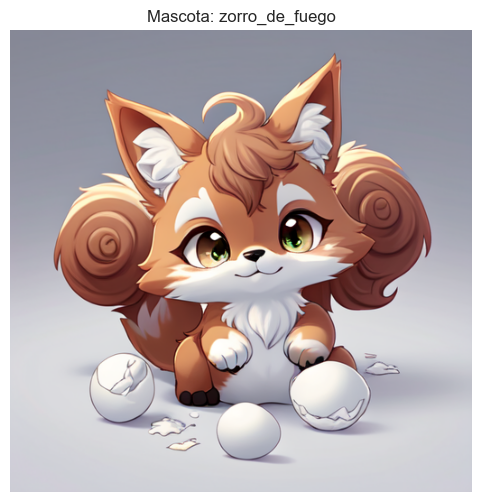

In [36]:
def generar_mascota(prompt: str, negative_prompt: str, seed: int,
                    num_inference_steps: int = 25, guidance_scale: float = 7.0):
    generator = torch.Generator(device=device).manual_seed(seed)
    return pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        generator=generator,
        width=512,
        height=512,
    ).images[0]

mascota_img = generar_mascota(prompt, negative, seed)

plt.figure(figsize=(6, 6))
plt.imshow(mascota_img)
plt.axis('off')
plt.title(f"Mascota: {mascota_elegida}")
plt.show()

Se visualiza la mascota generada. Como la seed se deriva del hash de los rasgos, si volvemos a correr la celda con los mismos rasgos obtenemos exactamente la misma criatura. Esto garantiza la identificabilidad ya que cada usuario tiene su mascota única y reproducible.

## **9. Pipeline completo end-to-end**

Encapsulamos todas las etapas en una sola función de forma a poder llamar el sistema completo con una línea. Esto es lo que se conectará a la interfaz de demo, por ejemplo con Gradio.

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['closed mouth , soft purple background']


  0%|          | 0/25 [00:00<?, ?it/s]

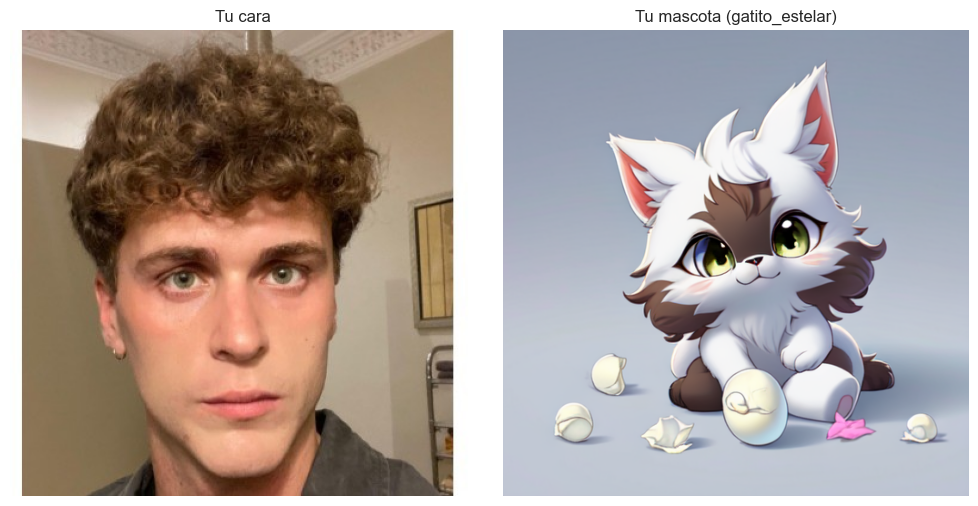


Seed única: 1613637630

Trazabilidad por rasgo:
  color_pelo         = castano              [conf=0.42, fuentes: resnet_kat, vit_kat, agus, geometria, clip]
  textura_pelo       = rizado               [conf=0.48, fuentes: resnet_kat, vit_kat, agus, clip]
  longitud_pelo      = corto                [conf=0.57, fuentes: resnet_kat, vit_kat, agus, clip]
  cejas              = normales             [conf=0.33, fuentes: resnet_kat, vit_kat, agus, clip]
  forma_ojos         = redonda              [conf=0.27, fuentes: resnet_kat, vit_kat, agus, geometria, clip]
  tamano_nariz       = mediana              [conf=0.41, fuentes: resnet_kat, vit_kat, agus, geometria, clip]
  forma_nariz        = respingona           [conf=0.32, fuentes: resnet_kat, vit_kat, agus, geometria, clip]
  grosor_labios      = medianos             [conf=0.52, fuentes: resnet_kat, vit_kat, agus, geometria, clip]
  pomulos            = normales             [conf=0.37, fuentes: resnet_kat, vit_kat, agus, geometria, clip]
  m

In [37]:
def pipeline_completo(imagen_rgb=None, ruta_archivo=None, mascota="gatito_estelar",
                      seed_override: int = None, mostrar: bool = True,
                      rasgos_corregidos_manualmente: dict = None):
    if imagen_rgb is None and ruta_archivo is not None:
        imagen_rgb = cargar_desde_archivo(ruta_archivo)
    if imagen_rgb is None:
        imagen_rgb = capturar_webcam()
    if imagen_rgb is None:
        raise RuntimeError("No se pudo obtener una imagen de entrada.")

    res_mp = face_mesh.process(imagen_rgb)
    if not res_mp.multi_face_landmarks:
        raise RuntimeError("No se detectó ninguna cara en la imagen.")
    lm = res_mp.multi_face_landmarks[0].landmark

    rasgos_geom_local = extraer_rasgos_geometricos(imagen_rgb, lm)

    preds_probs_local = {}
    for nombre, modelo in modelos.items():
        preds_probs_local[nombre] = predecir_probabilidades(modelo, imagen_rgb)

    # Verificador externo CLIP
    preds_clip_local = predecir_con_clip(imagen_rgb)

    rasgos_finales_local, confianzas_local, contribuciones_local = voto_suave_unificado(
        preds_probs_local, rasgos_geom_local, predicciones_clip=preds_clip_local
    )

    # Si se pasan correcciones manuales, las aplicamos
    if rasgos_corregidos_manualmente:
        for rasgo, valor_nuevo in rasgos_corregidos_manualmente.items():
            if rasgo in rasgos_finales_local and rasgos_finales_local[rasgo] != valor_nuevo:
                rasgos_finales_local[rasgo] = valor_nuevo
                contribuciones_local[rasgo] = ['manual']
                confianzas_local[rasgo] = 1.0

    prompt_local, negative_local = construir_prompt(rasgos_finales_local, mascota)
    seed_local = seed_override if seed_override is not None else hash_a_seed(rasgos_finales_local)

    mascota_local = generar_mascota(prompt_local, negative_local, seed_local)

    if mostrar:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(imagen_rgb)
        axes[0].axis('off')
        axes[0].set_title("Tu cara")
        axes[1].imshow(mascota_local)
        axes[1].axis('off')
        axes[1].set_title(f"Tu mascota ({mascota})")
        plt.tight_layout()
        plt.show()

    return {
        'rasgos':         rasgos_finales_local,
        'contribuciones': contribuciones_local,
        'confianzas':     confianzas_local,
        'prompt':         prompt_local,
        'negative':       negative_local,
        'seed':           seed_local,
        'mascota_img':    mascota_local,
    }

# Si ya pasaste por la UI de correccion en la seccion 5.5, podes pasar esos rasgos:
salida = pipeline_completo(
    imagen_rgb=imagen,
    mascota="gatito_estelar",
    rasgos_corregidos_manualmente=rasgos_finales,  # ya viene corregido de la UI
)

print(f"\nSeed única: {salida['seed']}")
print(f"\nTrazabilidad por rasgo:")
for k, v in salida['rasgos'].items():
    conf = salida['confianzas'].get(k, 0)
    contrib = ', '.join(salida['contribuciones'].get(k, []))
    print(f"  {k:18s} = {str(v):20s} [conf={conf:.2f}, fuentes: {contrib}]")

La salida del pipeline contiene todo lo necesario para reproducir y auditar la generación: el diccionario de rasgos consolidados, la trazabilidad de qué fuente aportó cada uno, las confianzas del ensemble, el prompt completo, el negative prompt, la seed y la imagen final. Esto es útil para debug y para guardar registros en sistemas de producción.

## **Conclusiones**

El pipeline v4 unifica el tratamiento de las cuatro fuentes de información (tres modelos preentrenados más geometría con MediaPipe) bajo un único mecanismo de soft voting. La diferencia conceptual respecto a la v3 es importante ya que en lugar de tratar a la geometría como un caso especial con reglas distintas (prioridad absoluta para ojos, fallback para el resto), ahora todas las fuentes se mezclan a través del mismo promedio ponderado.

La decisión central del diseño fue convertir la predicción categórica de la geometría a una distribución de probabilidades, lo cual nos permite combinarla aritméticamente con las probabilidades de los modelos sin necesidad de reglas if/else. El parámetro `confianza_base` controla cuán segura está la geometría de su predicción, y los pesos por rasgo modulan cuánto influye cada fuente en cada característica.

El sistema de pesos por rasgo es lo que le da poder al diseño: para color de ojos la geometría pesa 2.5 mientras los modelos pesan entre 0.8 y 1.0, lo cual asegura que la geometría domine en ese rasgo donde es naturalmente más confiable. Para gafas, pecas y vello facial la geometría pesa cero, así también, quedan totalmente en manos de los modelos. Para tono de piel los pesos están balanceados ya que ambas fuentes son razonables.

Las limitaciones que persisten son tres. Primero, los pesos por rasgo son hiperparámetros que conviene calibrar empíricamente sobre un conjunto de rostros etiquetados manualmente, ya que los valores actuales son heurísticas razonables pero no óptimas. Segundo, el orden de las clases en `CLASS_LABELS` debe coincidir con el orden de entrenamiento de cada modelo, lo cual se verifica con la celda de inspección. Tercero, el modelo ResNet de Kat usa una head binaria de 15 atributos que requiere un decodificador específico para mapear al vocabulario categórico, lo cual queda pendiente de la confirmación con Kat sobre el orden exacto de los atributos.

Como siguientes pasos lógicos, conviene envolver este pipeline en una interfaz Gradio que muestre los rasgos detectados con sus contribuciones y confianzas, así también, permita al usuario regenerar con seed alternativa. También sería útil agregar evaluación cuantitativa sobre un dataset pequeño de rostros etiquetados para optimizar los pesos por rasgo y el `confianza_base` de la geometría con grid search o similar.